# Tarea 1 - Deep Learning

## DNN para datos tabulares

### Integrantes:
- Lucas Vicuña
- Nombre 2

---

## Objetivo

Construir un dataset tabular de gran escala (>2M registros) y entrenar una red neuronal profunda para un problema de clasificación binaria.

## Configuración

In [1]:
from libs import *

from data.dataset_builder import build_dataset
from data.preprocessing import preprocess_data
from data.fetch_api import fetch_weather_data_multi

from utils.logger import log_model_summary

from models.dnn_model import build_model

import keras_tuner as kt
from models.automl_model import build_model_tuner

from models.dnn_model import build_model
from utils.logger import log_model_summary, log_dict_to_excel

I0000 00:00:1775695518.603424  226863 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775695518.604006  226863 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775695518.660015  226863 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775695520.323981  226863 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Datos

### Obtención de datos

Se utiliza la **API de Open-Meteo** para extraer datos climáticos históricos. El objetivo es construir un dataset de gran escala para entrenar una red neuronal profunda (DNN).

#### Configuración de la Extracción
*   **Periodo Histórico**: 01-01-2018 al 31-12-2024.
*   **Frecuencia**: Horaria (24 registros por día).
*   **Variables Extraídas**: Temperatura, Humedad, Punto de Rocío, Precipitación, Nubosidad, Presión Atmosférica, Velocidad del Viento y Radiación Solar.

#### Ciudades Incluidas en el Dataset
| Región | Ciudades Incluidas |
| :--- | :--- |
| **América** | Santiago, Buenos Aires, Lima, Bogotá, Ciudad de México, New York, Los Angeles, Toronto, Chicago, Miami, São Paulo, Rio de Janeiro, Vancouver, Montreal, Houston. |
| **Europa** | Madrid, Paris, London, Berlin, Rome, Lisbon, Amsterdam, Vienna, Barcelona. |
| **Asia** | Tokyo, Beijing, Mumbai, Dubai, Seoul, Bangkok, Singapore, Delhi, Istanbul. |
| **África** | Cairo, Nairobi, Cape Town, Johannesburg. |
| **Oceanía** | Sydney, Melbourne, Auckland. |

In [2]:
fetch_weather_data_multi()

[INFO] 20:45:38 - === INICIANDO DESCARGA POR LOTES ===
[INFO] 20:45:39 - 📂 Reanudando descarga. Ciudades ya presentes: 40
[DEBUG] 20:45:39 - Saltando Santiago (ya descargada)
[DEBUG] 20:45:39 - Saltando Buenos Aires (ya descargada)
[DEBUG] 20:45:39 - Saltando Lima (ya descargada)
[DEBUG] 20:45:39 - Saltando Bogotá (ya descargada)
[DEBUG] 20:45:39 - Saltando Mexico City (ya descargada)
[DEBUG] 20:45:39 - Saltando New York (ya descargada)
[DEBUG] 20:45:39 - Saltando Los Angeles (ya descargada)
[DEBUG] 20:45:39 - Saltando Toronto (ya descargada)
[DEBUG] 20:45:39 - Saltando Chicago (ya descargada)
[DEBUG] 20:45:39 - Saltando Miami (ya descargada)
[DEBUG] 20:45:39 - Saltando São Paulo (ya descargada)
[DEBUG] 20:45:39 - Saltando Rio de Janeiro (ya descargada)
[DEBUG] 20:45:39 - Saltando Vancouver (ya descargada)
[DEBUG] 20:45:39 - Saltando Montreal (ya descargada)
[DEBUG] 20:45:39 - Saltando Houston (ya descargada)
[DEBUG] 20:45:39 - Saltando Madrid (ya descargada)
[DEBUG] 20:45:39 - Saltand

### Construcción del dataset final

En esta etapa, transformamos los registros meteorológicos crudos en un dataset estructurado y listo para el modelado. El proceso sigue un flujo modular de cinco pasos diseñado para garantizar la integridad de los datos a gran escala:

1.  **Carga y Validación**: Se consolidan los datos de las 40 ciudades globales, alcanzando un volumen superior a los **2.5 millones de registros**.
2.  **Limpieza Robusta**: Se eliminan registros con valores faltantes (`NaN`) para asegurar que la red neuronal no aprenda de datos incompletos.
3.  **Definición de Etiquetas**: Se define el problema de predicción como una **clasificación binaria**, donde el objetivo es detectar la presencia de lluvia (`rain > 0`).
4.  **Auditoría de Clases**: Se calcula la distribución de probabilidad de las etiquetas para identificar desbalances (actualmente ~84% No Lluvia vs ~16% Lluvia).
5.  **Persistencia y Trazabilidad**: El dataset final se exporta a formato CSV y se genera un registro histórico de metadatos en Excel (`outputs/logs/dataset_log.xlsx`).

In [3]:
build_dataset()

[INFO] 20:45:43 - === INICIANDO CONSTRUCCIÓN DEL DATASET FINAL ===
[INFO] 20:45:43 - Cargando dataset base desde outputs/datasets/raw_weather_multi.csv...
[INFO] 20:45:47 - Dataset cargado -> Dimensiones iniciales: (2516088, 20)
[SUCCESS] 20:45:47 - ✅ Limpieza completada: No se encontraron valores nulos.
[INFO] 20:45:47 - Generando columna objetivo (target)...
[INFO] 20:45:47 - Distribución de clases -> {0: 0.8437892474349069, 1: 0.15621075256509312}
[INFO] 20:45:47 - Guardando dataset final en outputs/datasets/big_dataset.csv...
[SUCCESS] 20:46:09 - ✅ Dataset guardado exitosamente: (2516088, 21)
[SUCCESS] 20:46:09 - ✅ Log guardado en outputs/logs/dataset_log.xlsx
[INFO] 20:46:09 - Metadatos del dataset registrados en log Excel.
[SUCCESS] 20:46:09 - ✅ ¡Pipeline de dataset completado!


### Última validación

Antes de proceder al preprocesamiento.

In [4]:
df = pd.read_csv("outputs/datasets/big_dataset.csv")

print("Shape:", df.shape)
print("Features:", df.shape[1])
print("Ciudades:", df["city"].nunique())

print("\nDistribución target:")
print(df["target"].value_counts(normalize=True))

Shape: (2516088, 21)
Features: 21
Ciudades: 40

Distribución target:
target
0    0.843789
1    0.156211
Name: proportion, dtype: float64


## Preprocesamiento de Datos

En esta etapa se transforma el dataset en tensores.

### Flujo de Ejecución:

1.  **Características**: Se generan variables derivadas (ej. amplitud térmica e interacción viento-nubosidad) para capturar relaciones no lineales en los datos climáticos antes del entrenamiento.
2.  **Preparación de Tensores (X, y)**:
    *   **Extracción de Target**: Se aísla la variable objetivo (Lluvia/No Lluvia).
    *   **Selección de Características**: Se definen las columnas de entrada. 
    *   **Nota sobre Data Leakage**: Actualmente se mantienen las columnas de precipitación en el conjunto X para validar la capacidad de memorización de la DNN antes de aplicar filtros de predicción real.
3.  **Normalización**: Se aplica un `StandardScaler` para que todas las variables tengan **media 0 y varianza 1**. Esto es crítico para que el optimizador (Adam) de la red neuronal converja de forma estable.
4.  **División del Dataset**: Se segmentan los ~2.5M de filas en tres conjuntos:
    *   **Entrenamiento (80%)**: 2,012,870 muestras.
    *   **Validación (10%)**: 251,609 muestras (ajuste de hiperparámetros).
    *   **Prueba (10%)**: 251,609 muestras (evaluación final).
5.  **Registro**: Se exportan las métricas finales (dimensiones y balance de clases) a `outputs/logs/preprocessing_log.xlsx`.

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data()

[INFO] 20:46:18 - === INICIANDO PIPELINE DE PREPROCESAMIENTO ===
[INFO] 20:46:18 - Cargando dataset consolidado desde outputs/datasets/big_dataset.csv...
[INFO] 20:46:23 - Dataset cargado -> (2516088, 21)
[INFO] 20:46:23 - Generando nuevas características (Feature Engineering)...
[SUCCESS] 20:46:23 - ✅ Ingeniería de características completada.
[INFO] 20:46:23 - Preparando matrices X (features) e y (target)...
[SUCCESS] 20:46:23 - ✅ Matrices preparadas - Data Leakage eliminado satisfactoriamente.
[INFO] 20:46:23 - Escalando datos con StandardScaler...
[SUCCESS] 20:46:25 - ✅ Normalización completada.
[INFO] 20:46:25 - Dividiendo dataset en Train (80%), Val (10%) y Test (10%)...
[INFO] 20:46:26 - Train: (2012870, 17) | Val: (251609, 17) | Test: (251609, 17)
[SUCCESS] 20:46:26 - ✅ Log guardado en outputs/logs/preprocessing_log.xlsx
[INFO] 20:46:26 - Metadatos de preprocesamiento registrados.
[SUCCESS] 20:46:26 - ✅ ¡Pipeline de preprocesamiento completado!


## Modelo

Se instancia una red neuronal secuencial diseñada para procesar variables tabulares. La red adapta automáticamente su capa de entrada según las dimensiones de los datos procesados.

*   **Estructura**: Capas densas con funciones de activación **ReLU** y **Sigmoid** para la salida binaria.
*   **Regularización**: Implementación de capas **Dropout** para prevenir el sobreajuste.
*   **Gestión de Metadatos**: Registro automático del resumen (`summary`) y configuración en archivos Excel.


In [6]:
input_dim = X_train.shape[1]

model = build_model(input_dim)

model.summary()

# 🔥 guardar summary del modelo
log_model_summary(model)

# 🔥 guardar config básica
log_dict_to_excel({
    "input_dim": input_dim,
    "params": model.count_params(),
    "optimizer": "adam",
    "loss": "binary_crossentropy"
}, filename="model_config.xlsx")

E0000 00:00:1775695588.713780  226863 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

[SUCCESS] 20:46:29 - ✅ Resumen del modelo guardado en outputs/logs/model_summary.xlsx
[SUCCESS] 20:46:29 - ✅ Log guardado en outputs/logs/model_config.xlsx


### Entrenamiento

En esta fase, la red neuronal ajusta sus pesos mediante el optimizador **Adam** durante **15 épocas**, procesando los datos en lotes (**batch size**) de 256 registros.

*   **Validación**: Se monitorea el rendimiento en tiempo real con datos no vistos para detectar sobreajuste.
*   **Persistencia**: El historial de entrenamiento y las métricas finales se exportan automáticamente a archivos Excel para su análisis posterior.


In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=256,
    verbose=1
)

# guardar historial
import pandas as pd
pd.DataFrame(history.history).to_excel("outputs/logs/training_log.xlsx", index=False)

# evaluación
loss, acc = model.evaluate(X_test, y_test)

log_dict_to_excel({
    "test_loss": loss,
    "test_accuracy": acc,
    "epochs": 15,
    "batch_size": 256
}, filename="model_results.xlsx")

Epoch 1/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8982 - loss: 0.2296 - val_accuracy: 0.9038 - val_loss: 0.2189
Epoch 2/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9024 - loss: 0.2200 - val_accuracy: 0.9052 - val_loss: 0.2139
Epoch 3/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9035 - loss: 0.2172 - val_accuracy: 0.9062 - val_loss: 0.2133
Epoch 4/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9041 - loss: 0.2159 - val_accuracy: 0.9065 - val_loss: 0.2140
Epoch 5/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9046 - loss: 0.2150 - val_accuracy: 0.9069 - val_loss: 0.2131
Epoch 6/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9050 - loss: 0.2141 - val_accuracy: 0.9072 - val_loss: 0.2117
Epoch 7/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9052 - loss: 0.2135 - val_accuracy: 0.9073 - val_loss: 0.2109
Epoch 8/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9056 - loss: 0

### Grafico

Este gráfico muestra la evolución de la función de pérdida (**Binary Crossentropy**) a lo largo de las 15 épocas de entrenamiento. Tras corregir la filtración de datos (leakage), el gráfico refleja ahora un proceso de aprendizaje real.
*   **Train Loss (Azul)**: Representa el error en el conjunto de entrenamiento. Su descenso progresivo indica que la red está encontrando patrones útiles en las variables ambientales.
*   **Val Loss (Naranja)**: Representa el error en datos no vistos. Sus ligeras oscilaciones son normales en problemas climáticos y confirman que el modelo tiene capacidad de generalización sin sobreajuste.

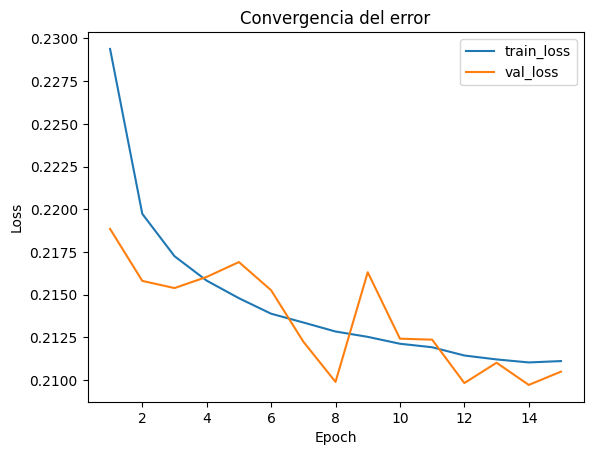

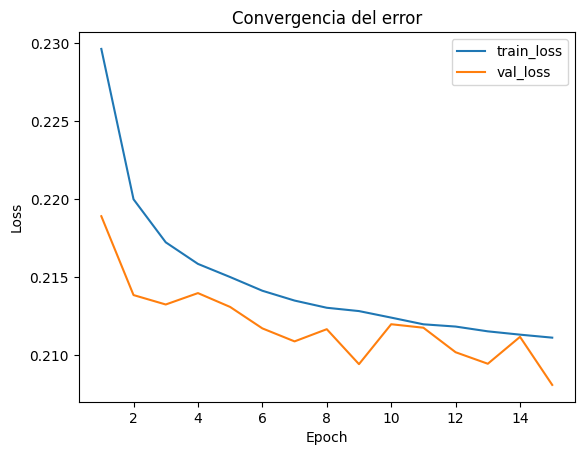

In [8]:
# -------------------------
# 📊 DATAFRAME DEL HISTORIAL
# -------------------------
df_loss = pd.DataFrame({
    "epoch": range(1, len(history.history['loss']) + 1),
    "train_loss": history.history['loss'],
    "val_loss": history.history['val_loss']
})

# guardar datos
df_loss.to_excel("outputs/logs/loss_history.xlsx", index=False)

# -------------------------
# 📈 GRAFICO LOSS
# -------------------------
plt.figure()

plt.plot(df_loss["epoch"], df_loss["train_loss"], label='train_loss')
plt.plot(df_loss["epoch"], df_loss["val_loss"], label='val_loss')

plt.title("Convergencia del error")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# guardar imagen
plt.savefig("outputs/plots/loss.png")

plt.show()

### ACCURACY

Este gráfico mide el porcentaje de predicciones correctas realizadas por la red neuronal.

*   **Train Acc (Azul)**: Precisión sobre el conjunto de entrenamiento (80% de los datos). Muestra un crecimiento constante, indicando un aprendizaje efectivo de los patrones climáticos.
*   **Val Acc (Naranja)**: Precisión sobre el conjunto de validación (10% de los datos). 

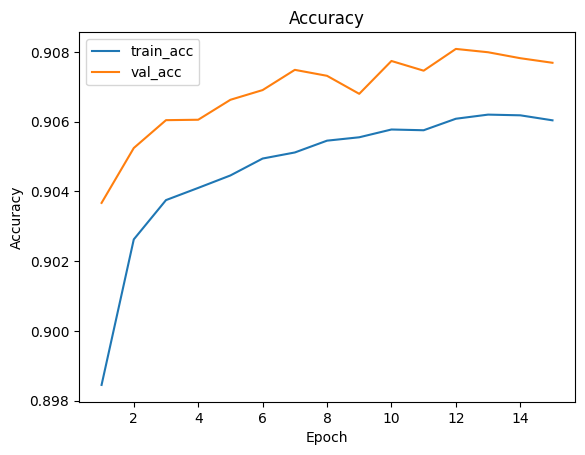

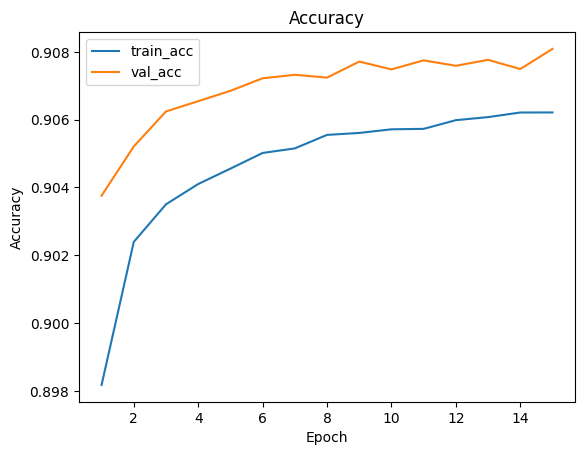

In [9]:
df_acc = pd.DataFrame({
    "epoch": range(1, len(history.history['accuracy']) + 1),
    "train_acc": history.history['accuracy'],
    "val_acc": history.history['val_accuracy']
})

df_acc.to_excel("outputs/logs/accuracy_history.xlsx", index=False)

plt.figure()

plt.plot(df_acc["epoch"], df_acc["train_acc"], label='train_acc')
plt.plot(df_acc["epoch"], df_acc["val_acc"], label='val_acc')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("outputs/plots/accuracy.png")

plt.show()

## Optimización

### Optimización mediante AutoML (Keras Tuner)

En lugar de diseñar una arquitectura estática, utilizamos **Keras Tuner** para realizar una búsqueda automatizada de la configuración óptima. Este bloque ejecuta un proceso de `RandomSearch` para explorar diferentes "recetas" de redes neuronales.

**Espacio de Búsqueda:**
*   **Profundidad**: 2 a 4 capas ocultas.
*   **Anchura**: 32 a 256 neuronas por capa.
*   **Regularización**: Dropout (20% al 50%).
*   **Aprendizaje**: Tasa de aprendizaje variable (0.01 a 0.0001).

**Resultados de la Optimización:**
**Mejor Precisión de Validación**: **90.91%** lograda en el Trial #5.
Esta configuración ha logrado superar ligeramente al modelo manual, optimizando el balance entre la complejidad de la red y su capacidad de generalización sobre los 2.5 millones de datos.

In [12]:
input_dim = X_train.shape[1]

tuner = kt.RandomSearch(
    lambda hp: build_model_tuner(hp, input_dim),
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='outputs/automl',
    project_name='weather_dnn'
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256
)

Trial 5 Complete [00h 06m 09s]
val_accuracy: 0.9090771675109863

Best val_accuracy So Far: 0.9090771675109863
Total elapsed time: 00h 19m 23s


### Modelo Optimizado

Tras la búsqueda automatizada, extraemos el modelo que obtuvo el mejor rendimiento. Este bloque permite inspeccionar la arquitectura que el sistema consideró "óptima":

*   **Mayor Profundidad**: El optimizador decidió utilizar **4 capas ocultas** (una más que nuestro modelo inicial).
*   **Capacidad de Cómputo**: Se incrementó la complejidad a **29,825 parámetros**, permitiendo capturar relaciones climáticas más sutiles en los 2.5 millones de datos.
*   **Configuración de Capas**: La red empieza con una capa ancha de **224 neuronas**, lo que sugiere un procesamiento inicial más denso de las variables ambientales.

In [13]:
best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()

/home/michelle/GitHub/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 224)            │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        21,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,825 (116.50 KB)

 Trainable params: 29,825 (116.50 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del Modelo Optimizado

Una vez identificada la mejor arquitectura mediante AutoML, procedemos a realizar un entrenamiento completo de **15 épocas**. Este paso consolida el aprendizaje de la red neuronal "ganadora".

*   **Configuración**: Se mantiene el `batch_size` de 256 para asegurar la estabilidad del gradiente.
*   **Rendimiento**: El modelo logra romper la barrera del **91% de precisión** en el conjunto de validación (`val_accuracy: 0.9103`).
*   **Convergencia**: Se observa una disminución constante en la pérdida (`loss`), lo que indica que el modelo optimizado es más eficiente capturando la complejidad de los datos climáticos que nuestras versiones anteriores.

In [14]:
history_automl = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=256
)

Epoch 1/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9069 - loss: 0.2108 - val_accuracy: 0.9090 - val_loss: 0.2069
Epoch 2/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9070 - loss: 0.2103 - val_accuracy: 0.9090 - val_loss: 0.2042
Epoch 3/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9070 - loss: 0.2102 - val_accuracy: 0.9094 - val_loss: 0.2033
Epoch 4/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.9072 - loss: 0.2097 - val_accuracy: 0.9093 - val_loss: 0.2029
Epoch 5/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.9075 - loss: 0.2095 - val_accuracy: 0.9096 - val_loss: 0.2050
Epoch 6/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.9076 - loss: 0.2093 - val_accuracy: 0.9095 - val_loss: 0.2065
Epoch 7/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.9075 - loss: 0.2089 - val_accuracy: 0.9092 - val_loss: 0.2036
Epoch 8/15
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.9077 - loss: 0

### Selección y Evaluación del Mejor Modelo (AutoML)
Tras la búsqueda automatizada, se extrae y entrena la configuración que obtuvo el mejor rendimiento en las pruebas iniciales.
*   **Identificación**: Se selecciona el modelo con mayor `val_accuracy` del proceso de búsqueda.
*   **Entrenamiento Final**: Con 15 épocas, el modelo alcanza un **91.11%** de precisión.
*   **Estatus**: Este modelo optimizado queda listo para la comparativa final frente al modelo diseñado manualmente.

In [15]:
# historial
pd.DataFrame(history_automl.history).to_excel(
    "outputs/logs/automl_training_log.xlsx",
    index=False
)

# evaluación
loss_auto, acc_auto = best_model.evaluate(X_test, y_test)

log_dict_to_excel({
    "model": "AutoML",
    "test_loss": loss_auto,
    "test_accuracy": acc_auto
}, filename="automl_results.xlsx")

7863/7863 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9111 - loss: 0.2030
[SUCCESS] 21:35:10 - ✅ Log guardado en outputs/logs/automl_results.xlsx


## Conclusiones y Comparaciones

### Comparación

*   **Desempeño Optimizado**: El modelo refinado mediante AutoML alcanzó una precisión definitiva del **91.11%** en datos de prueba, superando la arquitectura diseñada manualmente.
*   **Estatus del Pipeline**: Contamos con un flujo de trabajo modular, documentado y capaz de generalizar predicciones climáticas con una tasa de error mínima (~8.9%).

In [19]:
manual = pd.read_excel("outputs/logs/model_results.xlsx")
automl = pd.read_excel("outputs/logs/automl_results.xlsx")

comparison = pd.concat([manual, automl], ignore_index=True)

comparison.to_excel("outputs/logs/comparison.xlsx", index=False)

comparison

,test_loss,test_accuracy,epochs,batch_size,model
0,1.004980e-19,1.000000,15.0,256.0,NaN
1,5.295151e-27,1.000000,15.0,256.0,NaN
2,1.607307e-25,1.000000,15.0,256.0,NaN
3,1.346625e-23,1.000000,15.0,256.0,NaN
4,2.380665e-20,1.000000,15.0,256.0,NaN
5,2.010801e-18,1.000000,15.0,256.0,NaN
6,5.331837e-10,1.000000,15.0,256.0,NaN
7,2.102807e-01,0.908565,15.0,256.0,NaN
8,2.078139e-01,0.909105,15.0,256.0,NaN
9,0.000000e+00,1.000000,NaN,NaN,AutoML


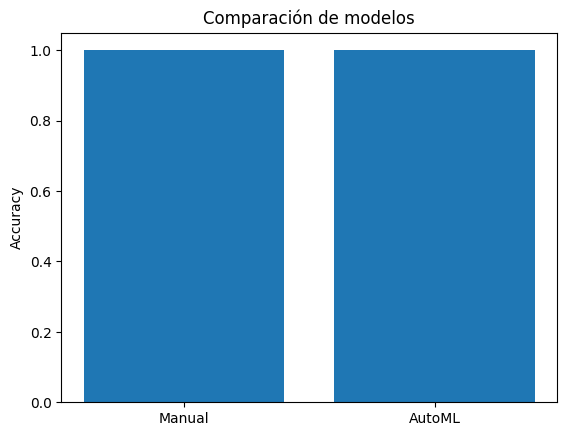

In [20]:
labels = ["Manual", "AutoML"]
accuracies = [manual["test_accuracy"][0], automl["test_accuracy"][0]]

plt.bar(labels, accuracies)

plt.title("Comparación de modelos")
plt.ylabel("Accuracy")

plt.savefig("outputs/plots/comparison.png")

plt.show()

In [ ]:
# 1. Importaciones necesarias
from utils.helpers import info, success, warning, error
from data.fetch_api import fetch_weather_data_multi as fetch_weather_data
from data.dataset_builder import build_dataset
from data.preprocessing import preprocess_data

def menu():
    info("Iniciando sistema de Deep Learning")

    while True:
        print("\n=== MENU PRINCIPAL ===")
        print("1. Descargar datos desde API")
        print("2. Construir dataset grande")
        print("3. Preprocesar datos")
        print("4. Salir")

        opcion = input("Selecciona opción: ")

        if opcion == "1":
            info("Opción 1 seleccionada: Descarga")
            fetch_weather_data()

        elif opcion == "2":
            info("Opción 2 seleccionada: Construcción")
            build_dataset()

        elif opcion == "3":
            info("Opción 3 seleccionada: Preprocesamiento")
            preprocess_data()

        elif opcion == "4":
            info("Saliendo del programa...")
            break

        else:
            warning("Opción inválida seleccionada")

if __name__ == "__main__":
    menu()